<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd
import numpy as np

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [2]:
#Importation du fichier population.csv
population = pd.read_csv('population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [3]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [4]:
#Consulter le nombre de colonnes 
print('Le fichier population contient',population.shape[1],'colonne(s).')
#La nature des données dans chacune des colonnes
print('\nLes valeurs de la colonne Zone sont de type',population['Zone'].dtype,', \ncelles de la colonne Année sont de type',population['Année'].dtype,'\net celles de la colonne Valeurs sont de type',population['Valeur'].dtype,'.')
#Le nombre de valeurs présentes dans chacune des colonnes
print('\nLa colonne Zone est composée de',population['Zone'].unique().shape[0],'valeurs uniques.\nLa colonne Année est composée de',population['Année'].unique().shape[0],'valeurs uniques.\nLa colonne Valeur est composée de',population['Valeur'].unique().shape[0],'valeurs uniques.')

Le fichier population contient 3 colonne(s).

Les valeurs de la colonne Zone sont de type object , 
celles de la colonne Année sont de type int64 
et celles de la colonne Valeurs sont de type float64 .

La colonne Zone est composée de 236 valeurs uniques.
La colonne Année est composée de 6 valeurs uniques.
La colonne Valeur est composée de 1413 valeurs uniques.


In [5]:
#Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [6]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population['Valeur'] *= 1000

In [7]:
#changement du nom de la colonne Valeur par Population
population = population.rename(columns={'Valeur': 'Population'})

In [8]:
#Correction nom de pays
population.loc[population['Zone'] == "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord",'Zone'] = "Royaume-Uni"

In [9]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [10]:
#Afficher les dimensions du dataset
print('Le fichier contient',dispo_alimentaire.shape[1],'colonnes et',dispo_alimentaire.shape[0],'lignes.')

Le fichier contient 18 colonnes et 15605 lignes.


In [11]:
#Consulter le nombre de colonnes
print('il y a',dispo_alimentaire.shape[1],'colonnes dans le fichier disponibilité alimentaire.')

il y a 18 colonnes dans le fichier disponibilité alimentaire.


In [12]:
#Correction de nom dans la colonne Zone
dispo_alimentaire.loc[dispo_alimentaire['Zone'] == 'Tchéquie (la)','Zone'] = 'Tchéquie'

In [13]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [14]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire = dispo_alimentaire.fillna(0)

In [15]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
cols = ['Aliments pour animaux', 'Autres Utilisations', 'Disponibilité intérieure','Exportations - Quantité', 'Importations - Quantité', 'Nourriture', 'Pertes', 'Production', 'Semences', 'Traitement', 'Variation de stock']
dispo_alimentaire[cols] = dispo_alimentaire[cols] * 1000000

In [16]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [17]:
#Afficher les dimensions du dataset
print('Le fichier contient',aide_alimentaire.shape[1],'colonnes et',aide_alimentaire.shape[0],'lignes.')

Le fichier contient 4 colonnes et 1475 lignes.


In [18]:
#Consulter le nombre de colonnes
print('il y a',aide_alimentaire.shape[1],'colonnes dans le fichier aide alimentaire.')

il y a 4 colonnes dans le fichier aide alimentaire.


In [19]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [20]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire = aide_alimentaire.rename(columns = {'Pays bénéficiaire' : 'Zone','Valeur' : 'Aide_alimentaire'})

In [21]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Aide_alimentaire'] = aide_alimentaire['Aide_alimentaire']*1000

In [22]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Zone,Année,Produit,Aide_alimentaire
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.4 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [23]:
#Afficher les dimensions du dataset
print('Le fichier contient',sous_nutrition.shape[1],'colonnes et',sous_nutrition.shape[0],'lignes.')

Le fichier contient 3 colonnes et 1218 lignes.


In [24]:
#Consulter le nombre de colonnes
print('il y a',sous_nutrition.shape[1],'colonnes dans le fichier sous nutrition.')

il y a 3 colonnes dans le fichier sous nutrition.


In [25]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [26]:
#Conversion de la colonne sous nutrition en numérique (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'],errors='coerce')
#Puis remplacement des NaN en 0
sous_nutrition['Valeur'] = sous_nutrition['Valeur'].fillna(0)

In [27]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition = sous_nutrition.rename(columns={'Valeur' :'sous_nutrition'})

In [28]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['sous_nutrition'] = sous_nutrition['sous_nutrition']*1000000

In [29]:
#Correction de nom de Zone
sous_nutrition.loc[sous_nutrition['Zone'] == "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord",'Zone'] = 'Royaume-Uni'

In [30]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Analyses</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [31]:
#Calul de l'année à prendre en compte par rapport à la période donnée dans le fichier sous-nutrition
sous_nutrition[['Année_debut','Année_fin']] = sous_nutrition['Année'].str.split(pat='-',expand=True)
sous_nutrition = sous_nutrition.rename(columns={'Année':'Période'})
sous_nutrition['Année'] = pd.to_numeric(sous_nutrition['Année_fin']) -1
sous_nutrition = sous_nutrition.drop(columns=['Année_debut','Année_fin'])
sous_nutrition

,Zone,Période,sous_nutrition,Année
0,Afghanistan,2012-2014,8600000.0,2013
1,Afghanistan,2013-2015,8800000.0,2014
2,Afghanistan,2014-2016,8900000.0,2015
3,Afghanistan,2015-2017,9700000.0,2016
4,Afghanistan,2016-2018,10500000.0,2017
...,...,...,...,...
1213,Zimbabwe,2013-2015,0.0,2014
1214,Zimbabwe,2014-2016,0.0,2015
1215,Zimbabwe,2015-2017,0.0,2016
1216,Zimbabwe,2016-2018,0.0,2017


In [32]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
sous_nutrition_pop = pd.merge(sous_nutrition,population, on=['Zone','Année'], how='inner')
sous_nutrition_pop = sous_nutrition_pop.loc[sous_nutrition_pop['Année'] == 2017,:]

In [33]:
#Affichage du dataset
sous_nutrition_pop.head()

,Zone,Période,sous_nutrition,Année,Population
4,Afghanistan,2016-2018,10500000.0,2017,36296113.0
10,Afrique du Sud,2016-2018,3100000.0,2017,57009756.0
16,Albanie,2016-2018,100000.0,2017,2884169.0
22,Algérie,2016-2018,1300000.0,2017,41389189.0
28,Allemagne,2016-2018,0.0,2017,82658409.0


In [34]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
print('Il y avait',int(sous_nutrition_pop['sous_nutrition'].sum()),'personnes en état de sous nutrition dans le monde en 2017')

Il y avait 535700000 personnes en état de sous nutrition dans le monde en 2017


In [35]:
#% de personnes en sous-nutrition par pays
sous_nutrition_pop['Sous_nutrition(%)'] = round(sous_nutrition_pop['sous_nutrition']/sous_nutrition_pop['Population']*100,2)
sous_nutrition_pop

,Zone,Période,sous_nutrition,Année,Population,Sous_nutrition(%)
4,Afghanistan,2016-2018,10500000.0,2017,36296113.0,28.93
10,Afrique du Sud,2016-2018,3100000.0,2017,57009756.0,5.44
16,Albanie,2016-2018,100000.0,2017,2884169.0,3.47
22,Algérie,2016-2018,1300000.0,2017,41389189.0,3.14
28,Allemagne,2016-2018,0.0,2017,82658409.0,0.00
...,...,...,...,...,...,...
1192,Venezuela (République bolivarienne du),2016-2018,8000000.0,2017,29402484.0,27.21
1198,Viet Nam,2016-2018,6500000.0,2017,94600648.0,6.87
1204,Yémen,2016-2018,0.0,2017,27834819.0,0.00
1210,Zambie,2016-2018,0.0,2017,16853599.0,0.00


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [36]:
#Combien mange en moyenne un être humain ? Source => 
print('Un être humain consomme en moyenne 2 940 kcal par jour selon le site de la FAO.\nSource : https://www.fao.org/4/y3557f/y3557f15.htm')

Un être humain consomme en moyenne 2 940 kcal par jour selon le site de la FAO.
Source : https://www.fao.org/4/y3557f/y3557f15.htm


In [37]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
population_2017 = population.loc[population['Année']==2017,:]
dispo_alimentaire_par_pays = dispo_alimentaire.groupby('Zone')[['Disponibilité alimentaire (Kcal/personne/jour)','Disponibilité alimentaire en quantité (kg/personne/an)','Disponibilité de matière grasse en quantité (g/personne/jour)','Disponibilité de protéines en quantité (g/personne/jour)']].sum().reset_index()
dispo_alimentaire_par_pays_pop = pd.merge(dispo_alimentaire_par_pays,population_2017,on='Zone',how='inner')

In [38]:
#Affichage du nouveau dataframe
dispo_alimentaire_par_pays_pop.head()

,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Année,Population
0,Afghanistan,2087.0,351.41,33.50,58.26,2017,36296113.0
1,Afrique du Sud,3020.0,564.80,83.58,85.33,2017,57009756.0
2,Albanie,3188.0,1095.54,106.48,111.37,2017,2884169.0
3,Algérie,3293.0,809.13,76.48,91.92,2017,41389189.0
4,Allemagne,3503.0,957.52,141.62,101.39,2017,82658409.0


In [39]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
dispo_alimentaire_par_pays_pop['dispo_kcal'] = (dispo_alimentaire_par_pays_pop['Disponibilité alimentaire (Kcal/personne/jour)']- 2940)*dispo_alimentaire_par_pays_pop['Population']
print('Au total, il manquait',round(dispo_alimentaire_par_pays_pop['dispo_kcal'].sum()/-1000000000,1),'milliards de kcal par jour en 2017 dans le monde pour atteindre les 2 940 kcal consommées \nen moyenne par jour et par personne.')

Au total, il manquait 483.5 milliards de kcal par jour en 2017 dans le monde pour atteindre les 2 940 kcal consommées 
en moyenne par jour et par personne.


In [40]:
#Calcul du nombre d'humains pouvant être nourris
dispo_alimentaire_par_pays_pop['dispo_total_pays']= dispo_alimentaire_par_pays_pop['Disponibilité alimentaire (Kcal/personne/jour)'] * dispo_alimentaire_par_pays_pop['Population']
dispo_mondiale = dispo_alimentaire_par_pays_pop['dispo_total_pays'].sum()
nb_pers_pouvant_etre_nourries = dispo_mondiale/2940
print("Si on considère que la consommation d'une personne par jour est de 2940 kcal, \nnous aurions pu nourir",round(nb_pers_pouvant_etre_nourries/1000000000,1),"milliards de personnes en 2017 avec les",round(dispo_mondiale/1000000000,1),"milliards \nde kcal dispo dans le monde par jour.")

Si on considère que la consommation d'une personne par jour est de 2940 kcal, 
nous aurions pu nourir 7.2 milliards de personnes en 2017 avec les 21182.2 milliards 
de kcal dispo dans le monde par jour.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [41]:
#Transfert des données avec les végétaux dans un nouveau dataframe
dispo_alimentaire_vege = dispo_alimentaire.loc[dispo_alimentaire['Origine'] == 'vegetale',['Zone','Disponibilité alimentaire (Kcal/personne/jour)']]
dispo_alimentaire_vege_pays = dispo_alimentaire_vege.groupby('Zone')['Disponibilité alimentaire (Kcal/personne/jour)'].sum().reset_index()
dispo_alimentaire_vege_pays_pop = pd.merge(dispo_alimentaire_vege_pays,population_2017,on='Zone',how='inner')

In [42]:
#Calcul du nombre de kcal disponible pour les végétaux
dispo_alimentaire_vege_pays_pop['dispo_vege_total_pays'] = dispo_alimentaire_vege_pays_pop['Disponibilité alimentaire (Kcal/personne/jour)'] * dispo_alimentaire_vege_pays_pop['Population']
dispo_mondiale_vege = dispo_alimentaire_vege_pays_pop['dispo_vege_total_pays'].sum()
print('Il y avait',round(dispo_mondiale_vege/1000000000,1),"milliards de kcal d'origine végétal disponible par jour dans le monde en 2017.")

Il y avait 17449.5 milliards de kcal d'origine végétal disponible par jour dans le monde en 2017.


In [43]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
nb_pers_pouvant_etre_nourries_vege = dispo_mondiale_vege/2940
print("Si on considère que la consommation d'une persone par jour est de 2940 kcal, \nnous aurions pu nourir",round(nb_pers_pouvant_etre_nourries_vege/1000000000,1),"milliards de personnes en 2017 avec les",round(dispo_mondiale_vege/1000000000,1),"milliards \nde kcal d'origine végétale dispo dans le monde par jour.")

Si on considère que la consommation d'une persone par jour est de 2940 kcal, 
nous aurions pu nourir 5.9 milliards de personnes en 2017 avec les 17449.5 milliards 
de kcal d'origine végétale dispo dans le monde par jour.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [44]:
#Calcul de la disponibilité totale
dispo_totale = dispo_alimentaire['Disponibilité intérieure'].sum()
print('La disponibilité totale dans le monde en 2017 est de',round(dispo_totale/1000000000000,2),'milliards de tonnes.')

La disponibilité totale dans le monde en 2017 est de 9.85 milliards de tonnes.


In [45]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 
print("Catégories d'utilisation de la disponibilité intérieure :")
liste = ['Aliments pour animaux','Nourriture','Semences','Traitement','Pertes','Autres Utilisations']
for cat in liste :
    print('\t',cat,':',round(dispo_alimentaire[cat].sum()/dispo_totale*100,2),'%')

Catégories d'utilisation de la disponibilité intérieure :
	 Aliments pour animaux : 13.24 %
	 Nourriture : 49.51 %
	 Semences : 1.57 %
	 Traitement : 22.38 %
	 Pertes : 4.61 %
	 Autres Utilisations : 8.78 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [46]:
#Création d'une liste avec toutes les variables
liste = ['Blé','Riz (Eq Blanchi)','Orge','Maïs','Seigle','Avoine','Millet','Sorgho','Céréales,Autres']

In [47]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
dispo_alimentaire_cereales = dispo_alimentaire.loc[dispo_alimentaire['Produit'].isin(liste),:]

In [48]:
#Affichage de la proportion d'alimentation animale
utilisation_alimentation_animale = round(dispo_alimentaire_cereales['Aliments pour animaux'].sum()/dispo_alimentaire_cereales['Disponibilité intérieure'].sum()*100,2)
print(utilisation_alimentation_animale,"% de la disponibilité en céréales est utilisé pour l'alimentation animale.")

35.91 % de la disponibilité en céréales est utilisé pour l'alimentation animale.


In [49]:
#Affichage de la proportion d'alimentation humaine
utilisation_alimentation_humaine = round(dispo_alimentaire_cereales['Nourriture'].sum()/dispo_alimentaire_cereales['Disponibilité intérieure'].sum()*100,2)
print(utilisation_alimentation_humaine,"% de la disponibilité en céréales est utilisé pour l'alimentation humaine.")

43.02 % de la disponibilité en céréales est utilisé pour l'alimentation humaine.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [50]:
#Création de la colonne proportion par pays
pires_pays_sous_nutrition = sous_nutrition_pop.loc[:,['Zone','Sous_nutrition(%)']].sort_values('Sous_nutrition(%)', ascending = False).head(10)

In [51]:
#affichage après trie des 10 pires pays
pires_pays_sous_nutrition

,Zone,Sous_nutrition(%)
472,Haïti,48.26
946,République populaire démocratique de Corée,47.19
652,Madagascar,41.06
622,Libéria,38.28
604,Lesotho,38.25
1102,Tchad,37.96
970,Rwanda,35.06
730,Mozambique,32.81
1120,Timor-Leste,32.17
4,Afghanistan,28.93


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [52]:
#calcul du total de l'aide alimentaire par pays
aide_alimentaire_depuis_2013 = aide_alimentaire.groupby(['Zone'])['Aide_alimentaire'].sum().reset_index()

In [53]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
pays_avec_plus_aide_alimentaire = aide_alimentaire_depuis_2013.sort_values('Aide_alimentaire',ascending=False).head(10)
pays_avec_plus_aide_alimentaire

,Zone,Aide_alimentaire
50,République arabe syrienne,1858943000
75,Éthiopie,1381294000
70,Yémen,1206484000
61,Soudan du Sud,695248000
60,Soudan,669784000
30,Kenya,552836000
3,Bangladesh,348188000
59,Somalie,292678000
53,République démocratique du Congo,288502000
43,Niger,276344000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [54]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
aide_alimentaire_par_an_par_pays = aide_alimentaire.groupby(['Zone','Année'])['Aide_alimentaire'].sum().reset_index()
aide_alimentaire_par_an_par_pays

,Zone,Année,Aide_alimentaire
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000
...,...,...,...
223,Égypte,2013,1122000
224,Équateur,2013,1362000
225,Éthiopie,2013,591404000
226,Éthiopie,2014,586624000


In [55]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
pays = ['République arabe syrienne','Éthiopie','Yémen','Soudan du Sud','Soudan']

In [56]:
#On filtre sur le dataframe avec notre liste
aide_alimentaire_cinq_pays = aide_alimentaire_par_an_par_pays.loc[aide_alimentaire_par_an_par_pays['Zone'].isin(pays),:].copy()

In [57]:
# Affichage des pays avec l'aide alimentaire par année
aide_alimentaire_cinq_pays

,Zone,Année,Aide_alimentaire
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [58]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_par_pers_par_jour_par_pays = dispo_alimentaire.groupby('Zone')['Disponibilité alimentaire (Kcal/personne/jour)'].sum().reset_index()

In [59]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
pays_moins_dispo = dispo_par_pers_par_jour_par_pays.sort_values('Disponibilité alimentaire (Kcal/personne/jour)',ascending=True).head(10)
pays_moins_dispo

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
128,République centrafricaine,1879.0
166,Zambie,1924.0
91,Madagascar,2056.0
0,Afghanistan,2087.0
65,Haïti,2089.0
133,République populaire démocratique de Corée,2093.0
151,Tchad,2109.0
167,Zimbabwe,2113.0
114,Ouganda,2126.0
154,Timor-Leste,2129.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [60]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
pays_plus_dispo = dispo_par_pers_par_jour_par_pays.sort_values('Disponibilité alimentaire (Kcal/personne/jour)',ascending=False).head(10)
pays_plus_dispo

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
11,Autriche,3770.0
16,Belgique,3737.0
159,Turquie,3708.0
171,États-Unis d'Amérique,3682.0
74,Israël,3610.0
72,Irlande,3602.0
75,Italie,3578.0
89,Luxembourg,3540.0
168,Égypte,3518.0
4,Allemagne,3503.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [61]:
#création d'un dataframe avec uniquement la Thaïlande 
dispo_thailande = dispo_alimentaire.loc[dispo_alimentaire['Zone'] == 'Thaïlande',['Zone','Produit','Production','Exportations - Quantité','Importations - Quantité','Variation de stock','Disponibilité intérieure']]

In [62]:
#Calcul de la sous nutrition en Thaïlande
sous_nutri_thailande = sous_nutrition_pop.loc[sous_nutrition_pop['Zone'] == 'Thaïlande','Sous_nutrition(%)'].iloc[0]
print(sous_nutri_thailande,'% des personnes sont en état de sous-nutrition en Thaïlande')

8.96 % des personnes sont en état de sous-nutrition en Thaïlande


In [63]:
# On calcule la proportion exportée en fonction de la proportion
export_par_rapport_production_manioc = round((dispo_thailande.loc[dispo_thailande['Produit'] == 'Manioc','Exportations - Quantité']).iloc[0]/(dispo_thailande.loc[dispo_thailande['Produit'] == 'Manioc','Production']).iloc[0]*100,2)
print('La Thaïlande exporte',export_par_rapport_production_manioc,'% de sa product0ion de Manioc alors que',sous_nutri_thailande,'% de ses habitants sont en état de sous-nutrition.')

La Thaïlande exporte 83.41 % de sa product0ion de Manioc alors que 8.96 % de ses habitants sont en état de sous-nutrition.


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [64]:
#Calcul du pourcentage de personnes en sous-nutrition dans le monde
pour_pers_sous_nutrition = round(sous_nutrition_pop['sous_nutrition'].sum()/sous_nutrition_pop['Population'].sum()*100,2)
print(pour_pers_sous_nutrition,'% des personnes sont en état de sous-nutrition dans le monde en 2017')

7.1 % des personnes sont en état de sous-nutrition dans le monde en 2017


In [65]:
#Importation librairies data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

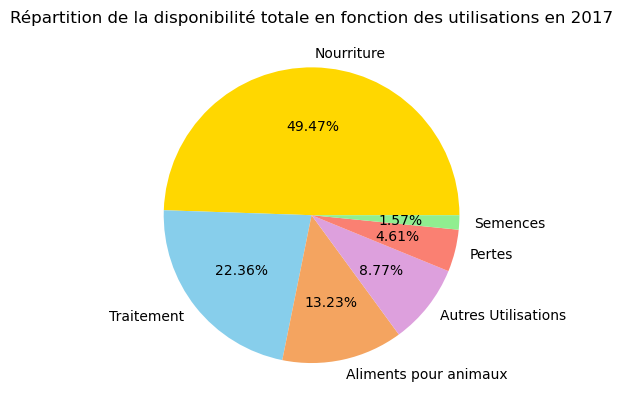

In [66]:
#Pie chart répartition de la disponibilité totale en fonction des utilisations en 2017
liste = ['Aliments pour animaux','Nourriture','Semences','Traitement','Pertes','Autres Utilisations']
pourcentage = []
for cat in liste :
    pourcentage.append(round(dispo_alimentaire[cat].sum()/dispo_totale*100,2))
dispo_alimentaire_par_utilisation = pd.DataFrame(pourcentage)
dispo_alimentaire_par_utilisation = dispo_alimentaire_par_utilisation.rename(columns={0:'Pourcentage'})
dispo_alimentaire_par_utilisation['Utilisations'] = liste
dispo_alimentaire_par_utilisation = dispo_alimentaire_par_utilisation.sort_values('Pourcentage',ascending=False)
couleurs_cat = {'Aliments pour animaux': 'sandybrown','Nourriture': 'gold','Semences': 'lightgreen','Traitement': 'skyblue','Pertes': 'salmon','Autres Utilisations': 'plum'}
plt.pie(x=dispo_alimentaire_par_utilisation['Pourcentage'],labels=dispo_alimentaire_par_utilisation['Utilisations'],autopct='%.2f%%',colors=[couleurs_cat[u] for u in dispo_alimentaire_par_utilisation['Utilisations']])
plt.title('Répartition de la disponibilité totale en fonction des utilisations en 2017')
plt.show()

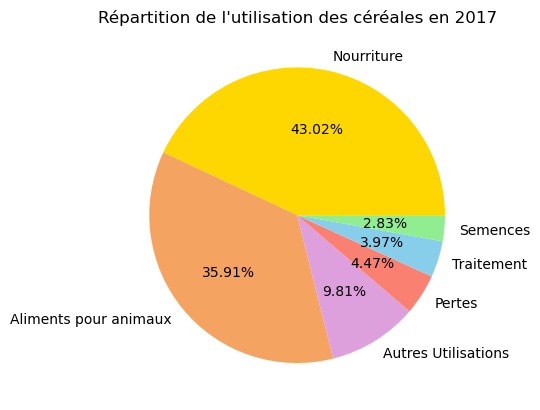

In [67]:
#Pie chart répartition de l'utilisation des céréales en 2017
liste = ['Aliments pour animaux','Nourriture','Semences','Traitement','Pertes','Autres Utilisations']
dispo_cereales = pd.DataFrame({'Utilisations': liste,'Pourcentage': [np.nan]*len(liste)})
for cat in liste:
    dispo_cereales.loc[dispo_cereales['Utilisations'] == cat,'Pourcentage'] = round(dispo_alimentaire_cereales[cat].sum()/dispo_alimentaire_cereales['Disponibilité intérieure'].sum()*100,2)
dispo_cereales = dispo_cereales.sort_values('Pourcentage',ascending=False)
plt.pie(x=dispo_cereales['Pourcentage'],labels=dispo_cereales['Utilisations'],autopct='%.2f%%',colors=[couleurs_cat[u] for u in dispo_cereales['Utilisations']])
plt.title("Répartition de l'utilisation des céréales en 2017")
plt.show()

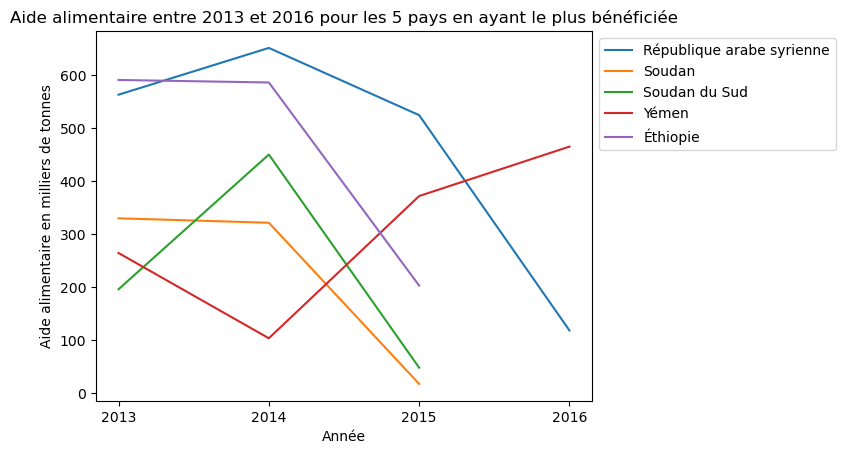

In [68]:
#Diagramme en lignes représentant l'évolution de l'aide alimentaire pour les 5 pays en ayant le plus bénéficiés entre 2013 et 2016
aide_alimentaire_cinq_pays['Aide alimentaire en milliers de tonnes'] = aide_alimentaire_cinq_pays['Aide_alimentaire']/1000000
sns.lineplot(data = aide_alimentaire_cinq_pays,x='Année',y='Aide alimentaire en milliers de tonnes',hue='Zone')
plt.title('Aide alimentaire entre 2013 et 2016 pour les 5 pays en ayant le plus bénéficiée')
plt.xticks((2013,2014,2015,2016))
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

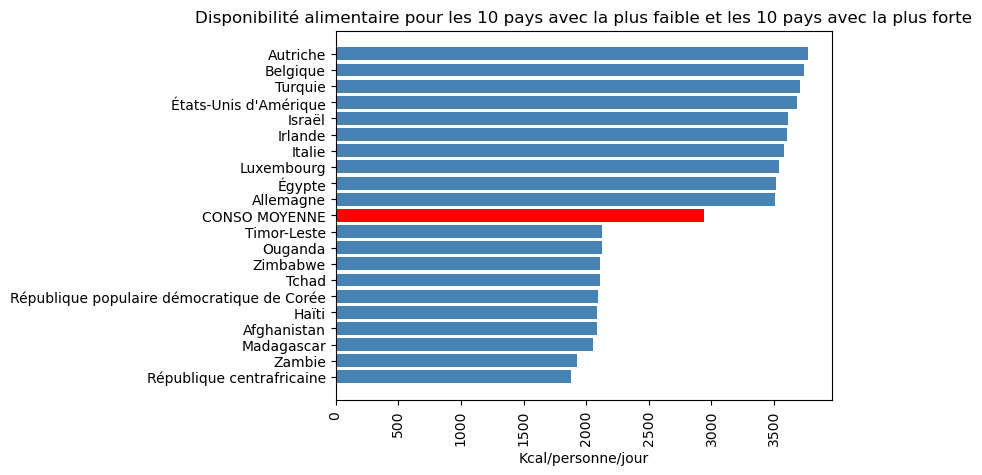

In [69]:
#Représentation des disponibilités alimentaires pour les 10 pays avec la plus forte dispo et les 10 pays avec la moins forte dispo
moyenne = pd.DataFrame({'Zone':'CONSO MOYENNE','Disponibilité alimentaire (Kcal/personne/jour)':2940},index=[0])
data = pd.concat([pays_moins_dispo,moyenne,pays_plus_dispo.sort_values('Disponibilité alimentaire (Kcal/personne/jour)')], ignore_index=True)
plt.barh(y=data['Zone'],width=data['Disponibilité alimentaire (Kcal/personne/jour)'],
        color=['red' if z=='CONSO MOYENNE' else 'steelblue' for z in data['Zone']])
plt.xticks(rotation=90)
plt.title('Disponibilité alimentaire pour les 10 pays avec la plus faible et les 10 pays avec la plus forte')
plt.xlabel('Kcal/personne/jour')
plt.show()